In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load the dataset
data = pd.read_excel('walking_data.xlsx')

# Clean column names (fixes your earlier KeyError too)
data.columns = data.columns.str.strip().str.lower()

# Now safe to use
print(data.columns.tolist())
data.set_index('time', inplace=True)

['time', 'user.x', 'user.z', 'user.vx', 'user.vz', 'user.yaw', 'pois.distance', 'pois.angle']


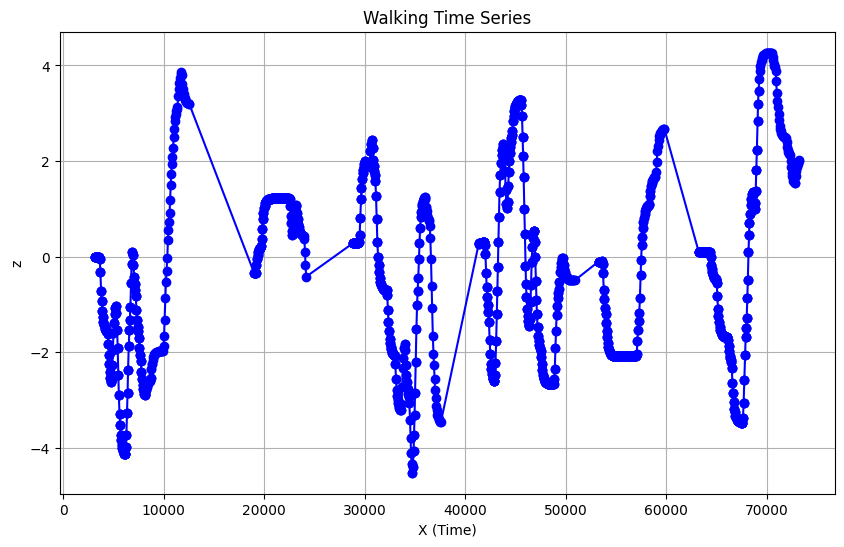

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(data['user.x'], marker='o', linestyle='-',color='blue')
plt.title('Walking Time Series')
plt.xlabel('X (Time)')
plt.ylabel('z')
plt.grid(True)
plt.show()

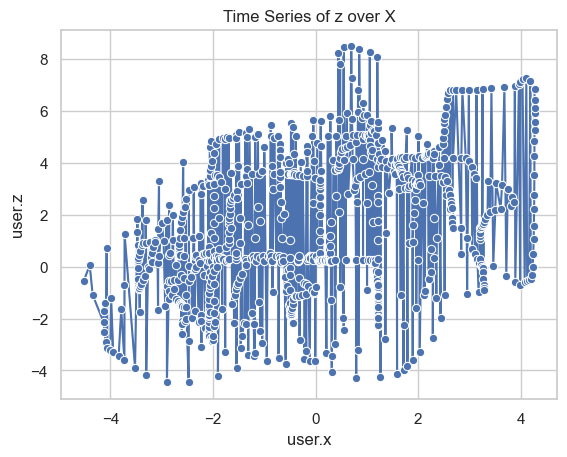

In [44]:
sns.set(style="whitegrid")
sns.lineplot(x='user.x', y='user.z', data=data, marker='o')
plt.title('Time Series of z over X')
plt.show()

In [ ]:
fig = px.line(data, x='user.x', y='user.z', title='Interactive Time Series of z over X')

fig.update_layout(
    xaxis_title='X (Time)',
    yaxis_title='z',
    template='plotly_white'
)

fig.show()

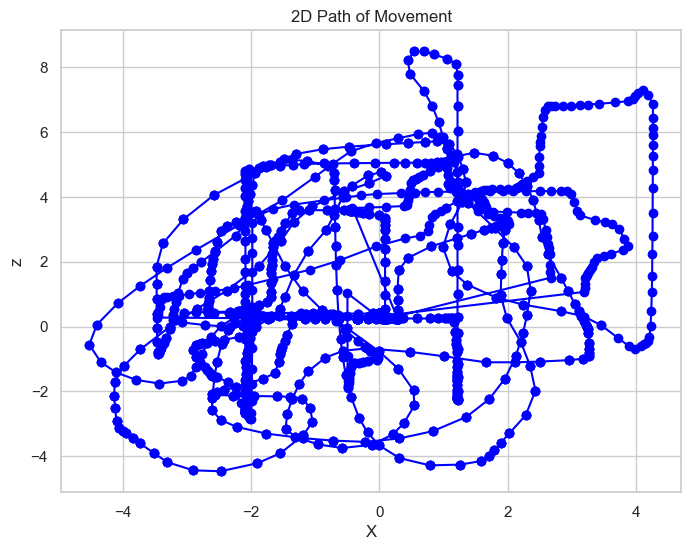

In [53]:
# Plot path
plt.figure(figsize=(8, 6))
plt.plot(data['user.x'], data['user.z'], marker='o', linestyle='-', color='blue')
plt.title('2D Path of Movement')
plt.xlabel('X')
plt.ylabel('z')
plt.grid(True)

plt.show()

In [54]:
scaler = MinMaxScaler()
sclaed_data = scaler.fit_transform(data)

# split the data int train and test sets
train_size = int(len(sclaed_data) * 0.8)
train_data = sclaed_data[:train_size]
test_data = sclaed_data[train_size:]

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 12     # Number of time steps to look back
X_train, y_train = create_sequences(train_data, seq_length)
X_test, y_test = create_sequences(test_data, seq_length)

In [55]:
model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100


c:\Users\JetPa\anaconda3\envs\mnist_tf2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 7 and 1 for '{{node sequential_1_1/lstm_1_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_1_1/lstm_1_1/strided_slice_2, sequential_1_1/lstm_1_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [?,7], [1,200].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(None, 7), dtype=float32)
  • states=('tf.Tensor(shape=(None, 50), dtype=float32)', 'tf.Tensor(shape=(None, 50), dtype=float32)')
  • training=True

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


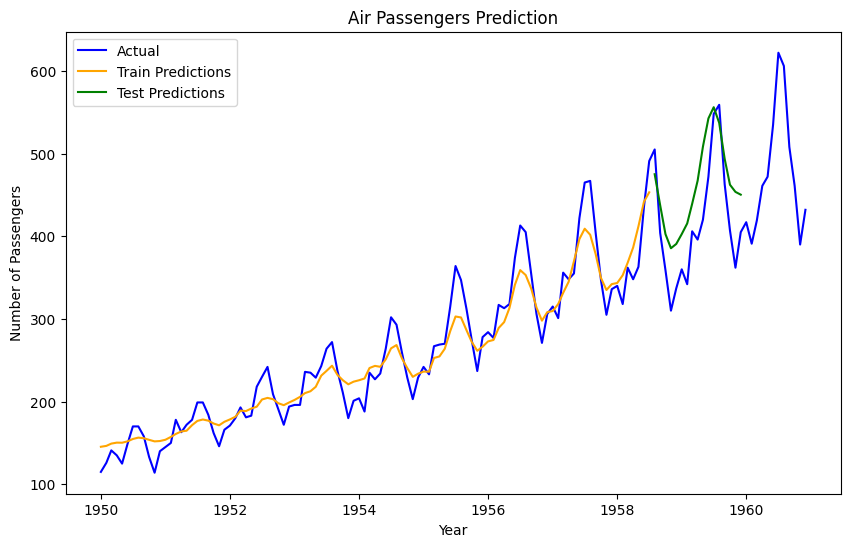

In [8]:
# Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Inverse transform the predictions and actual values
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)

#Plot predictions
plt.figure(figsize=(10, 6))

#plot actual data
plt.plot(data.index[seq_length:], data['#Passengers'][seq_length:], label='Actual', 
         color='blue')

#plot training predictions
plt.plot(data.index[seq_length:seq_length+len(train_predictions)], train_predictions,
          label='Train Predictions', color='orange')

#plot test predictions
test_pred_index = range(seq_length+len(train_predictions),
                        seq_length+len(train_predictions)+len(test_predictions))
plt.plot(data.index[test_pred_index], test_predictions, label='Test Predictions',
         color='green')

plt.title('Air Passengers Prediction')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

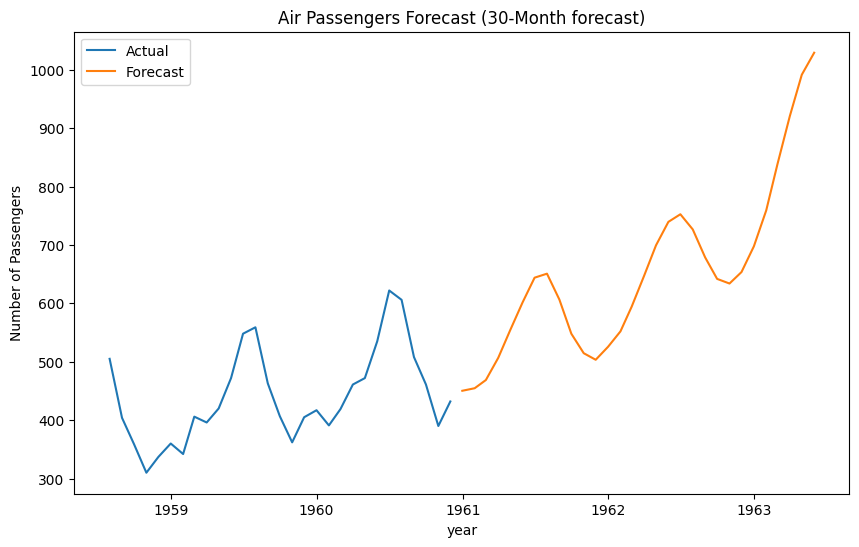

In [13]:
#forcasting
forcast_period = 30
forecast = []

#use the last sequence from the test data to make predictions
last_sequence = X_test[-1]

for _ in range(forcast_period):
    #reshape the sequence to match the input shape of the model
    current_sequence = last_sequence.reshape(1, seq_length, 1)
    #predict the next value
    next_prediction = model.predict(current_sequence)[0][0]
    #append the predicition to the forecast list
    forecast.append(next_prediction)
    #update the last sequence by removing the first element and appending the predicted value
    last_sequence = np.append(last_sequence[1:], next_prediction)

#inverse transform the forecasted values
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))

#plot the forcasted values
plt.figure(figsize=(10, 6))
plt.plot(data.index[-len(test_data):], scaler.inverse_transform(test_data), label='Actual')
plt.plot(pd.date_range(start=data.index[-1], periods=forcast_period, freq='ME'), forecast,
          label='Forecast')
plt.title('Air Passengers Forecast (30-Month forecast)')
plt.xlabel('year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()
